In [1]:
# ============================================================
# HAM10000 SIMPLE MULTIMODAL ML
#
# Inputs:
#   image pixels from hmnist_28_28_RGB.csv
#   sex
#   localization
#
# Outputs:
#   classification: dx
#   regression: age
#
# No AutoGluon.
# No PyTorch.
# No TensorFlow.
# Only sklearn.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ============================================================
# 1. Paths
# ============================================================

DATA_DIR = Path("/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP")

metadata_path = DATA_DIR / "HAM10000_metadata.csv"
pixels_path = DATA_DIR / "hmnist_28_28_RGB.csv"

print("Metadata exists:", metadata_path.exists())
print("Pixels CSV exists:", pixels_path.exists())

assert metadata_path.exists()
assert pixels_path.exists()

Metadata exists: True
Pixels CSV exists: True


In [2]:
# ============================================================
# 2. Load data
# ============================================================

meta = pd.read_csv(metadata_path)
pixels = pd.read_csv(pixels_path)

print("Metadata shape:", meta.shape)
print("Pixels shape:", pixels.shape)

display(meta.head())
display(pixels.head())

Metadata shape: (10015, 7)
Pixels shape: (10015, 2353)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [3]:
# ============================================================
# 1. Dataset path
# ============================================================

DATA_DIR = Path("/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP")

metadata_path = DATA_DIR / "HAM10000_metadata.csv"
images_part_1 = DATA_DIR / "HAM10000_images_part_1"
images_part_2 = DATA_DIR / "HAM10000_images_part_2"

print("DATA_DIR exists:", DATA_DIR.exists())
print("Metadata exists:", metadata_path.exists())
print("Images part 1 exists:", images_part_1.exists())
print("Images part 2 exists:", images_part_2.exists())

DATA_DIR exists: True
Metadata exists: True
Images part 1 exists: True
Images part 2 exists: True


In [4]:
# ============================================================
# 2. Load metadata
# ============================================================

df = pd.read_csv(metadata_path)

print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# ============================================================
# 3. Find image paths
# ============================================================

image_paths = (
    list(images_part_1.glob("*.jpg"))
    + list(images_part_2.glob("*.jpg"))
)

print("Number of image files found:", len(image_paths))

image_map = {p.stem: str(p) for p in image_paths}

df["image"] = df["image_id"].map(image_map)

print("Missing image paths:", df["image"].isna().sum())

df[["image_id", "image"]].head()

Number of image files found: 10015
Missing image paths: 0


,image_id,image
0,ISIC_0027419,/Users/nikos/Documents/Master/Thesis/Software/...
1,ISIC_0025030,/Users/nikos/Documents/Master/Thesis/Software/...
2,ISIC_0026769,/Users/nikos/Documents/Master/Thesis/Software/...
3,ISIC_0025661,/Users/nikos/Documents/Master/Thesis/Software/...
4,ISIC_0031633,/Users/nikos/Documents/Master/Thesis/Software/...


In [6]:
# ============================================================
# 4. Keep useful columns
# ============================================================

data = df[
    [
        "image_id",
        "lesion_id",
        "image",
        "dx",
        "age",
        "sex",
        "localization",
    ]
].dropna().copy()

# Clean strings
data["dx"] = data["dx"].astype(str).str.lower()
data["sex"] = data["sex"].astype(str).str.lower()
data["localization"] = data["localization"].astype(str).str.lower()

print("Usable data shape:", data.shape)
data.head()

Usable data shape: (9958, 7)


,image_id,lesion_id,image,dx,age,sex,localization
0,ISIC_0027419,HAM_0000118,/Users/nikos/Documents/Master/Thesis/Software/...,bkl,80.0,male,scalp
1,ISIC_0025030,HAM_0000118,/Users/nikos/Documents/Master/Thesis/Software/...,bkl,80.0,male,scalp
2,ISIC_0026769,HAM_0002730,/Users/nikos/Documents/Master/Thesis/Software/...,bkl,80.0,male,scalp
3,ISIC_0025661,HAM_0002730,/Users/nikos/Documents/Master/Thesis/Software/...,bkl,80.0,male,scalp
4,ISIC_0031633,HAM_0001466,/Users/nikos/Documents/Master/Thesis/Software/...,bkl,75.0,male,ear


dx
nv       6660
mel      1111
bkl      1089
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


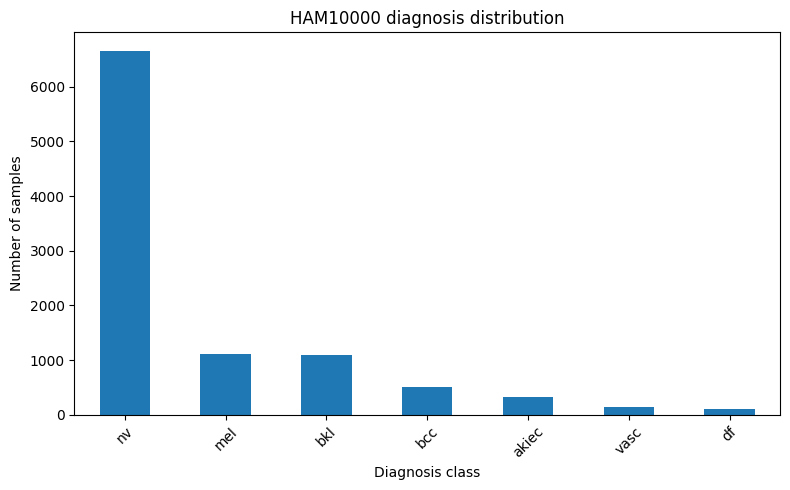

In [7]:
# ============================================================
# 5. Inspect class distribution
# ============================================================

print(data["dx"].value_counts())

plt.figure(figsize=(8, 5))
data["dx"].value_counts().plot(kind="bar")
plt.xlabel("Diagnosis class")
plt.ylabel("Number of samples")
plt.title("HAM10000 diagnosis distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


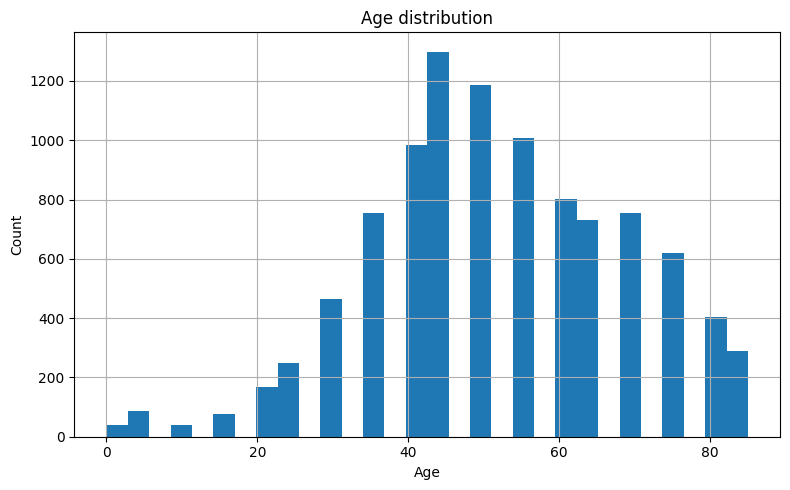

In [8]:
# ============================================================
# 6. Inspect age distribution
# ============================================================

print(data["age"].describe())

plt.figure(figsize=(8, 5))
data["age"].hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution")
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 7. Lesion-level train/test split
#
# This avoids leakage:
# the same lesion_id cannot appear in both train and test.
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_idx, test_idx = next(
    gss.split(data, groups=data["lesion_id"])
)

train_data = data.iloc[train_idx].reset_index(drop=True)
test_data = data.iloc[test_idx].reset_index(drop=True)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

train_lesions = set(train_data["lesion_id"])
test_lesions = set(test_data["lesion_id"])

print("Shared lesions between train and test:", len(train_lesions & test_lesions))

Train shape: (7950, 7)
Test shape: (2008, 7)
Shared lesions between train and test: 0


In [10]:
# ============================================================
# 8. Prepare classification and regression dataframes
# ============================================================

classification_cols = ["image", "sex", "localization", "dx"]
regression_cols = ["image", "sex", "localization", "age"]

train_cls = train_data[classification_cols].copy()
test_cls = test_data[classification_cols].copy()

train_reg = train_data[regression_cols].copy()
test_reg = test_data[regression_cols].copy()

print("Classification train:")
display(train_cls.head())

print("Regression train:")
display(train_reg.head())

Classification train:


,image,sex,localization,dx
0,/Users/nikos/Documents/Master/Thesis/Software/...,male,scalp,bkl
1,/Users/nikos/Documents/Master/Thesis/Software/...,male,scalp,bkl
2,/Users/nikos/Documents/Master/Thesis/Software/...,male,ear,bkl
3,/Users/nikos/Documents/Master/Thesis/Software/...,male,ear,bkl
4,/Users/nikos/Documents/Master/Thesis/Software/...,female,back,bkl


Regression train:


,image,sex,localization,age
0,/Users/nikos/Documents/Master/Thesis/Software/...,male,scalp,80.0
1,/Users/nikos/Documents/Master/Thesis/Software/...,male,scalp,80.0
2,/Users/nikos/Documents/Master/Thesis/Software/...,male,ear,75.0
3,/Users/nikos/Documents/Master/Thesis/Software/...,male,ear,75.0
4,/Users/nikos/Documents/Master/Thesis/Software/...,female,back,70.0


In [11]:
# ============================================================
# 9. Train multimodal classification model
#
# Task:
#   image + sex + localization -> dx
# ============================================================

clf = MultiModalPredictor(
    label="dx",
    problem_type="multiclass",
    path=str(DATA_DIR / "autogluon_ham10000_dx"),
)

clf.fit(
    train_data=train_cls,
    time_limit=600,   # 10 minutes; increase later
)

NameError: name 'MultiModalPredictor' is not defined